In [92]:
import pandas as pd
import numpy as np

In [93]:
# Dataset
# Read in the data
df = pd.read_csv('../dataset/tweet_data/tweet_data.csv')

In [94]:
df.sample(10)

,textID,tweet_text,sentiment
17413,1753451986,some of my new followers are pretty cool tweep...,positive
11371,1694791882,White House joins social networking sites &gt;...,positive
3232,1961424200,Evermore &amp; End of Fashion rocks! My poor f...,negative
9227,1966265378,everyone has left me and gone to bed,negative
17977,1753648090,#f1 soon good luck brawn and mclaren fix up l...,positive
16760,1753197797,FUCK EM,negative
6979,1964644332,plus it hurts seeing sum1 you love falling for...,negative
13326,1750930056,just bought a good chocolate and a magazine......,positive
5376,1963190126,@debby41 Your not alone im gutted i missed the...,negative
4702,1962739629,I'm so sleep deprived but it's to hot to sleep.,negative


## Visualise data

In [95]:
import matplotlib.pyplot as plt

           textID  tweet_text
sentiment                    
negative     8830        8830
positive     9897        9897


<BarContainer object of 2 artists>

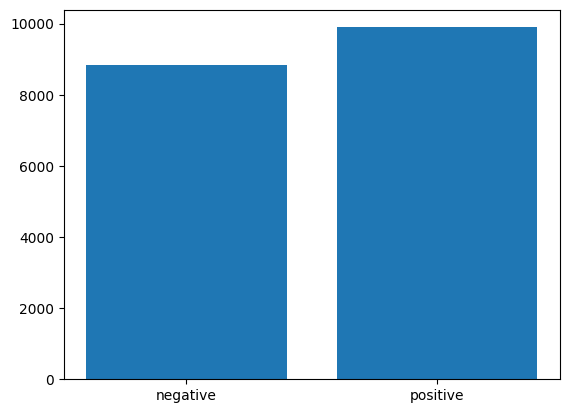

In [96]:
sentiment_count = df.groupby('sentiment').count()
# show number of count of positive and negative
print(sentiment_count)
# Showing the bar plot of positive and negative
plt.bar(sentiment_count.index.values, sentiment_count['tweet_text'])

# Using module to show most used words for pos and neg tweets

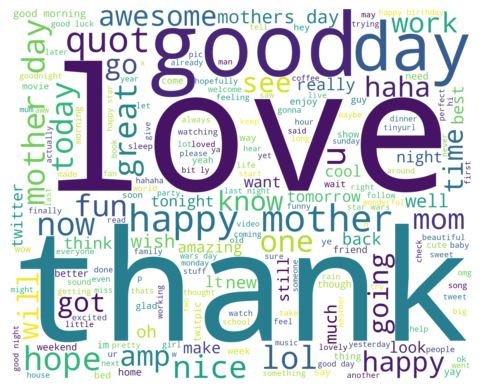

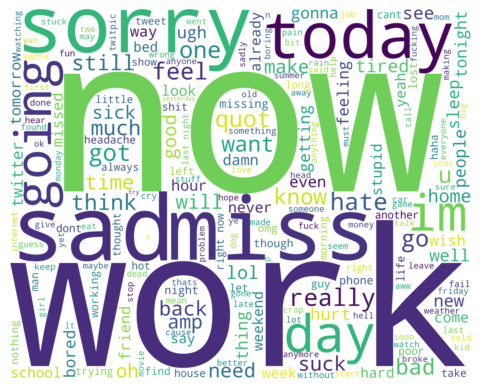

In [97]:
from wordcloud import WordCloud

positive_tweets = df[df['sentiment'] == 'positive']
negative_tweets = df[df['sentiment'] == 'negative']

txt_positive = " ".join(tweet.lower() for tweet in positive_tweets['tweet_text'])
txt_negative = " ".join(tweet.lower() for tweet in negative_tweets['tweet_text'])

# Generate a word cloud image
wordcloud_positive = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_positive)
wordcloud_negative = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_negative)

# Display the generated image:
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.show()

plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.show()



# Text Normalization

In [98]:
import re

In [99]:
# example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!"

In [100]:
# Remove emojis
import emoji

In [101]:

def convert_emoji_to_text(text):
    text = emoji.demojize(text) # Converting the emoji to their word meaning
    text = text.replace(":"," ") # Replacing the colon symbol with a space
    return text

#print(convert_emoji_to_text(example))


In [102]:
# Remove links
def remove_links(text, replace_with=""):
    text = re.sub('(http|https):\/\/\S+', replace_with, text) # regex to remove any links starting with http or https
    return text
#print (remove_links(example))

In [103]:
# Remove hashtags
def remove_hashtags(text, replace_with=""):
    text = re.sub('#+', replace_with, text) # regex to remove any hashtags
    return text

#print (remove_hashtags(example))

In [104]:
# General cleaning / text normalization

In [105]:
# Making string all lowercase
def lower_case_string(text):
    return text.lower()

#print (lower_case_string(example))

In [106]:
# Removing repeated characters
def remove_letter_repetitions(text):
    return re.sub(r'(.)\1+', r'\1\1', text) # regex to remove repeated chars, firstly matches a char which is repeated more than once, then replaces it with the same char twice

#print (remove_letter_repetitions(example))

# Removing punctuation repetitions
def remove_punctuation_repetitions(text, replace_with=""):
    return re.sub(r'[\?\.\!]+(?=[\?\.\!])', replace_with, text) # regex to remove repeated punctuation, firstly matches a punctuation which is repeated more than once, then replaces it with a single punctuation

#print (remove_punctuation_repetitions(example))

In [107]:
# Working with contractions
# Using a contraction dictionary we can replace contractions with their full form
import contractions

In [108]:
# Replacing contractions with their full form: e.g I'm -> I am
def replace_contractions(text):
    text = contractions.fix(text) # Using built in method from contractions library
    return text

#print(replace_contractions(example))

# Tokenization
- stop words
- punctionation
- numbers

In [109]:
# Using nltk library
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [110]:
def tokenize(text):
    tokens = word_tokenize(text)
    return tokens

#print(tokenize(example))

In [111]:
# Using a more complex and complete tokenizer
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [112]:
stop_words = set(stopwords.words('english')) # Getting the stop words from nltk
print(stop_words)

{'ourselves', 'can', 'but', 'same', "should've", 'how', 'doing', 'down', "shouldn't", 'his', 'wasn', 'no', 'ma', 'whom', 'what', 'was', 'having', "won't", "aren't", 'them', 'won', 'why', 'few', 'to', 'before', 'as', 'mightn', "don't", 're', 'of', 'for', 'it', 'aren', 'very', 'myself', 'couldn', 'such', 'themselves', 'she', 'the', 'that', 'too', 'through', "weren't", 'ain', 'here', 'some', "wasn't", 'not', 'or', 'this', "you've", 'out', 'both', "haven't", 'while', 'under', 'should', 'into', 'herself', 'shan', 'isn', "hasn't", "she's", 'has', 'your', 'below', 'being', 'needn', 'mustn', 'be', 'doesn', "that'll", "mightn't", 'when', 'me', 'did', 'off', 'y', "you're", 'until', "you'd", 'own', 't', 'yourself', "didn't", 'between', "it's", 'against', 'more', 'who', "couldn't", 'they', 'have', 'don', "shan't", 'yours', 'which', "wouldn't", 'i', 'itself', 'an', 'after', 've', 'are', 'because', 'd', 'a', 'theirs', 'each', 'only', 'll', "mustn't", 'about', 'her', 'at', 'o', 'haven', "isn't", 'my'

In [113]:
# Depending if we want to keep punctuation, alphanumeric characters and stopwords we can use the following function with True or False
def custom_tokenization(text, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False):
    token_list = word_tokenize(text)

    if not keep_punctuation:
        token_list = [token for token in token_list if token not in text.punctuation()] # Add only if not in the punctuation list
    if not keep_alphanum:
        token_list = [token for token in token_list if token.isalpha()] # Add only if is a letter
    if not keep_stopwords:
        stop_words = set(stopwords.words('english'))
        stop_words.discard('not', 'below', 'above') # Remove stop words which are relevant for sentiment analysis from the stop words list !NOTE: Can add more words to be excluded
        token_list = [token for token in token_list if token not in stop_words] # Add only if not in the stop words list

    return token_list

## Stemming

In [114]:
from nltk.stem import PorterStemmer 
from nltk.stem import LancasterStemmer # more agressive stemming
from nltk.stem import SnowballStemmer # better than porter and newer
#NOTE: can look at more stemming algos

In [115]:
porter_stemmer = PorterStemmer()
lancaster_stemmer = LancasterStemmer()
snowball_stemmer = SnowballStemmer('english')


In [116]:
# Function to stem tokens given a stemming algorithm
def stemming_tokens(tokens, stemmer):
    token_list = [stemmer.stem(token) for token in tokens] # Add the new stemmed token to the list
    return token_list

In [117]:
#print(stemming_tokens(tokenize(example), snowball_stemmer))

# Preprocessing text

In [128]:
# Processing the string/text

def process_text(text):
    # Removing links and converting emojis to text
    p_txt = remove_links(text)
    p_txt = convert_emoji_to_text(p_txt)

    # Removing hashtags, making string lowercase, removing repeated characters and punctuation and replacing contractions
    p_txt = remove_hashtags(p_txt)
    p_txt = lower_case_string(p_txt)
    p_txt = remove_letter_repetitions(p_txt)
    p_txt = remove_punctuation_repetitions(p_txt)
    p_txt = replace_contractions(p_txt)
    
    # Tokenizing the string
    p_txt = tokenize(p_txt)
    # p_txt = custom_tokenization(p_txt)

    # Stemming the tokens
    p_txt = stemming_tokens(p_txt, snowball_stemmer)
    return p_txt

example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!"
print(process_text(example))

Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!
Tom loved this fooooooood spot. This is their website for more info   I'm sure we'll go here again.  smiling_face_with_smiling_eyes  #food #greatfood #BESTFOOD!!!!!!
tom loved this food spot. this is their website for more info  i am sure we will go here again.  smiling_face_with_smiling_eyes  food greatfood bestfood!
['tom', 'loved', 'this', 'food', 'spot', '.', 'this', 'is', 'their', 'website', 'for', 'more', 'info', 'i', 'am', 'sure', 'we', 'will', 'go', 'here', 'again', '.', 'smiling_face_with_smiling_eyes', 'food', 'greatfood', 'bestfood', '!']
['tom', 'love', 'this', 'food', 'spot', '.', 'this', 'is', 'their', 'websit', 'for', 'more', 'info', 'i', 'am', 'sure', 'we', 'will', 'go', 'here', 'again', '.', 'smiling_face_with_smiling_ey', 'food', 'greatfood', 'bestfood', '!']
